In [29]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re


directory = './1_200G_4376.5109_4377.4913_fac_lat0_long0_r0_v4000_i90/'

#band
#directory = './1_4376.5109_4377.4913_band_lat45_90_v4000'




# print the header of the first file to get the simulation parameters
first_csv = next(Path('.').glob(f'{directory}/transit_lc*.csv'), None)
if first_csv:
    with open(first_csv, 'r') as f:
        header = f.readline()
        print("Simulation Parameters:")
        print(header.strip())
        print(' ')
else:
    print("No .csv files found to read the header from.")

lightcurves = {}
# read all the csv files in the directory and store the light curves in a dictionary based on wavelength
for csv_file in Path(directory).glob('transit_lc*.csv'):
    # Extract the wavelength from the filename using regex
    match = re.search(r'transit_lc_(\d+\.?\d*)\.csv', csv_file.name)
    if match:
        wavelength = float(match.group(1))
        data = np.loadtxt(csv_file, delimiter=',', skiprows=1)
        lightcurves[wavelength] = data
    else:
        print(f"Could not extract wavelength from filename: {csv_file.name}")

Simulation Parameters:
# disk_fill_phase_0=0.0, res2d=30, res3d=4, mode=faconly, fac_r=[0], fac_long=[0], fac_lat=[0], fac_band=False, fac_band_low=[-2.5], fac_band_high=[2.5], ld=power2, v_eq=4000, inc=90, rp=0.1808, b=-0.04, N=49, a=2, T=20, phi=0.5, hd_ld_file=test_phot.txt, fac_ld_file=test_fac_200G.txt
 


In [30]:
print(lightcurves.keys())

dict_keys([4376.9661, 4377.2287, 4377.3162, 4376.8085, 4377.3863, 4376.896, 4376.5284, 4376.931, 4377.3512, 4377.1061, 4376.5109, 4377.0361, 4377.0011, 4376.6509, 4376.861, 4377.2462, 4377.4388, 4376.826, 4376.7385, 4376.6684, 4377.4038, 4376.791, 4377.2987, 4377.0186, 4376.5459, 4377.2637, 4376.8785, 4376.721, 4377.0711, 4376.7034, 4376.9135, 4377.4213, 4377.1762, 4376.5634, 4376.8435, 4377.2812, 4377.0886, 4376.6334, 4377.1411, 4376.9836, 4377.3337, 4377.3688, 4377.1236, 4377.1937, 4376.7735, 4376.9485, 4377.1586, 4377.4563, 4377.4738, 4376.5809, 4376.6859, 4376.5984, 4377.0536, 4377.4913, 4376.6159, 4376.756, 4377.2112])


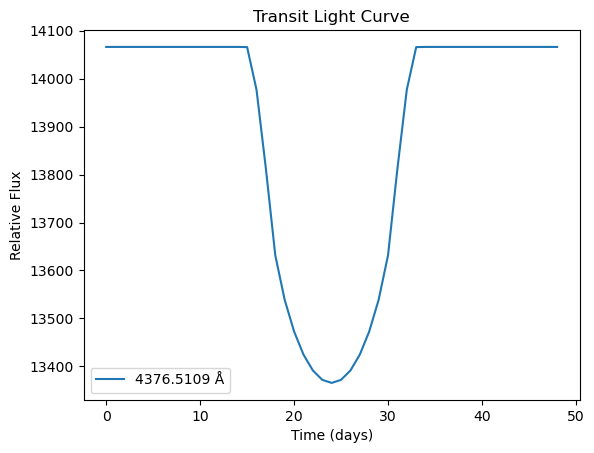

In [31]:
plt.plot(np.arange(len(lightcurves[4376.5109])), lightcurves[4376.5109], label='4376.5109 Å')
plt.xlabel('Time (days)')
plt.ylabel('Relative Flux')
plt.title('Transit Light Curve')
plt.legend()
plt.show()

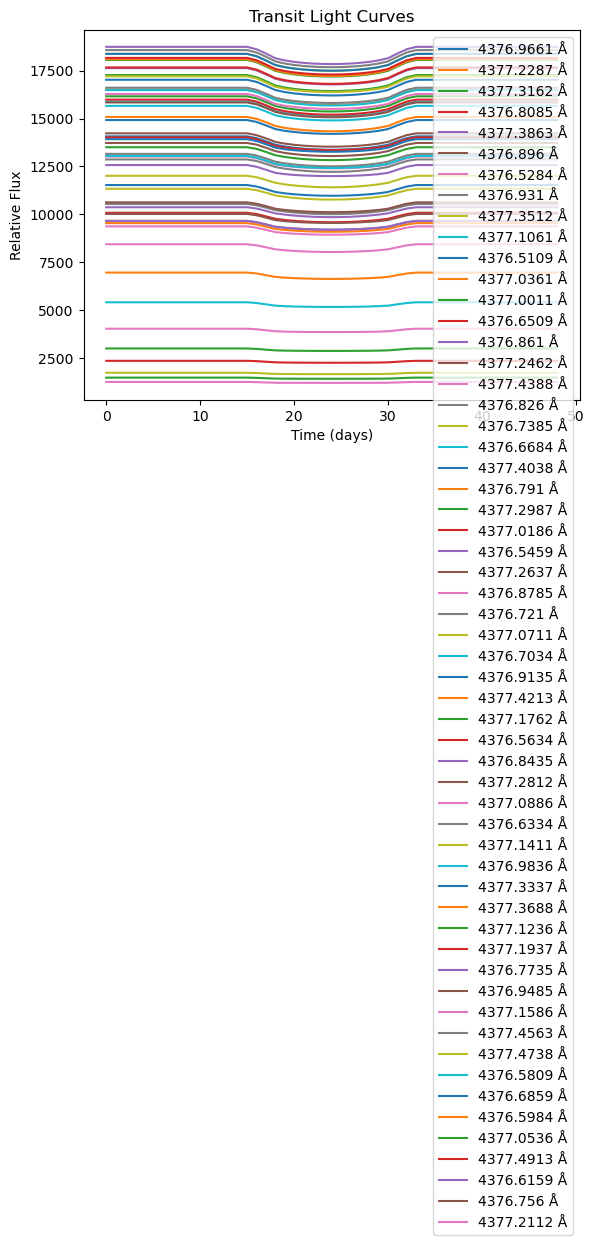

In [32]:
#plot all the lightcurves on the same plot
for wavelength, data in lightcurves.items():
    plt.plot(np.arange(len(data)), data, label=f'{wavelength} Å')
plt.xlabel('Time (days)')
plt.ylabel('Relative Flux')
plt.title('Transit Light Curves')
plt.legend()
plt.show()

## Doppler shift across the transit

The cells below read the per-wavelength `transit_disk_inp*.npy` / `wavelength_shifts_inp*.csv` / `transit_positions_inp*.csv`
files written by `transit_disk_save` (see `simulator.py`'s `transit_lc(..., returndisc=True, v_eq=...)`).
Each disc stack has shape `(N_position, H, W)`, one frame per transit time-step, with the planet's shadow
already masked out and (if `v_eq!=0`) the star rotating between frames.

This mirrors `1_analyze_disks.ipynb`'s per-pixel Doppler-shifted spectrum, but repeated at every transit
position instead of a single phase, and finishes with a spectrum-vs-time "Doppler shadow" plot showing how
the planet's shadow moves across the rotationally broadened line profile as it transits.

In [33]:
# Point this at the directory passed to transit_disk_save (lives in ../transit_disks/, one level up from
# this notebook's transit_lightcurves/ folder)
transit_directory = '../transit_disks/1_200G_4376.5109_4377.4913_fac_lat0_long0_r0_v4000_i90/'

disc_files = sorted(Path(transit_directory).glob('transit_disk_inp*.npy'))
if not disc_files:
    raise FileNotFoundError(f"No files found matching pattern: transit_disk_inp*.npy in {transit_directory}")

def parse_wavelength(p):
    m = re.search(r'inp([0-9.]+)\.npy$', p.name)
    return float(m.group(1)) if m else np.nan

transit_discs = {}
for f in disc_files:
    wl = parse_wavelength(f)
    transit_discs[wl] = np.load(f)

wavelengths_t = np.array(sorted(transit_discs.keys()))

shapes = {arr.shape for arr in transit_discs.values()}
if len(shapes) == 1:
    all_transit_discs = np.stack([transit_discs[wl] for wl in wavelengths_t], axis=0)
    # all_transit_discs shape: (num_wavelengths, num_positions, H, W)
    print("Stacked shape (Wavelength, Position, H, W):", all_transit_discs.shape)
else:
    raise ValueError("Shapes differ across wavelength files; every wavelength should share the same N/res2d.")

print(f"Loaded {len(transit_discs)} wavelength files")

Stacked shape (Wavelength, Position, H, W): (57, 49, 60, 60)
Loaded 57 wavelength files


wavelength_shifts_t shape (Wavelength, H, W): (57, 60, 60)
Planet positions shape (Position, 2): (49, 2)


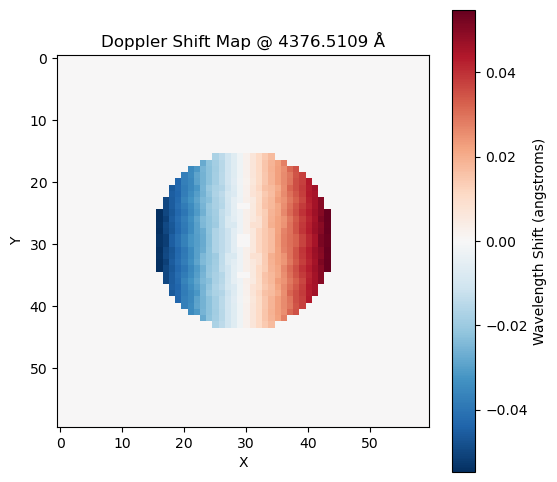

In [34]:
# Load the Doppler wavelength-shift map (one static map per wavelength, from the star's rotation) and the
# planet's (x, y) position at each transit time-step
shift_files = sorted(Path(transit_directory).glob('wavelength_shifts_inp*.csv'))
if not shift_files:
    raise FileNotFoundError("No files found matching pattern: wavelength_shifts_inp*.csv. "
                             "(This only gets written when transit_lc was run with v_eq!=0.)")

def parse_shift_wavelength(p):
    m = re.search(r'inp([0-9.]+)\.csv$', p.name)
    return float(m.group(1)) if m else np.nan

wavelength_shifts_by_wl = {}
for f in shift_files:
    wl = parse_shift_wavelength(f)
    wavelength_shifts_by_wl[wl] = np.loadtxt(f)

missing = [wl for wl in wavelengths_t if wl not in wavelength_shifts_by_wl]
if missing:
    raise ValueError(f"Missing shift maps for wavelengths: {missing}")

wavelength_shifts_t = np.stack([wavelength_shifts_by_wl[wl] for wl in wavelengths_t], axis=0)
print("wavelength_shifts_t shape (Wavelength, H, W):", wavelength_shifts_t.shape)

# Planet position is identical at a given transit index regardless of wavelength, so just read one file
pos_file = next(Path(transit_directory).glob('transit_positions_inp*.csv'))
positions = np.loadtxt(pos_file)
n_positions = positions.shape[0]
print("Planet positions shape (Position, 2):", positions.shape)

plt.figure(figsize=(6, 6))
plt.imshow(wavelength_shifts_t[0], cmap='RdBu_r')
plt.colorbar(label='Wavelength Shift (angstroms)')
plt.title(f'Doppler Shift Map @ {wavelengths_t[0]} Å')
plt.xlabel('X'); plt.ylabel('Y')
plt.show()

In [35]:
# Combine intensity + wavelength-shift channel per wavelength: (Position, H, W, C)
# channel 0 = intensity (with the planet's shadow already blocked out), channel 1 = wavelength shift (m)
all_transit_with_shift_by_wl = {
    wl: np.stack(
        [
            transit_discs[wl],
            np.broadcast_to(wavelength_shifts_by_wl[wl], transit_discs[wl].shape),
        ],
        axis=-1,
    )
    for wl in wavelengths_t
}

first_wl = wavelengths_t[0]
print(f"Example @ {first_wl}:", all_transit_with_shift_by_wl[first_wl].shape)
print("Per-wavelength shape: (Position, H, W, C), channels: 0=intensity, 1=wavelength_shift_in_m")

Example @ 4376.5109: (49, 60, 60, 2)
Per-wavelength shape: (Position, H, W, C), channels: 0=intensity, 1=wavelength_shift_in_m


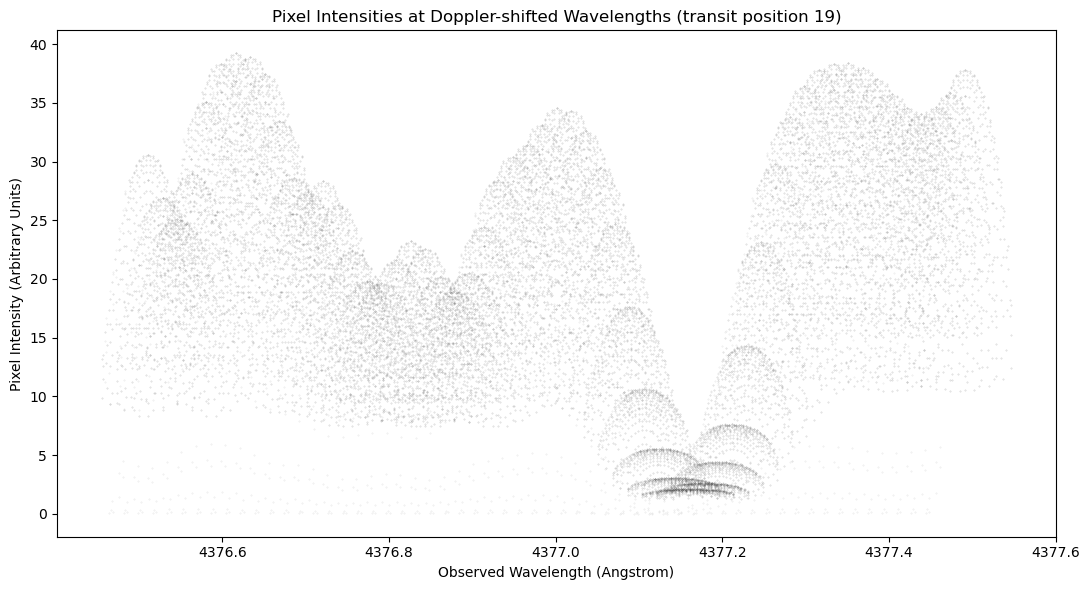

Num pixel points: 36195


In [42]:
# Per-pixel Doppler-shifted spectrum at a single transit time-step (same idea as 1_analyze_disks.ipynb's
# phase-0 scatter, just reusable for any transit position)
shift_scale = 1  # shift maps are stored in the same units as the wavelength filenames

def doppler_shifted_spectrum(position_idx):
    shifted_lambda_all = []
    intensity_all = []
    for wl in wavelengths_t:
        arr = all_transit_with_shift_by_wl[wl]
        intensity_2d = arr[position_idx, :, :, 0]
        dlam_2d = arr[position_idx, :, :, 1] * shift_scale
        lam_obs = wl + dlam_2d
        m = intensity_2d > 0  # keep only on-disc, unblocked pixels
        shifted_lambda_all.append(lam_obs[m].ravel())
        intensity_all.append(intensity_2d[m].ravel())
    return np.concatenate(shifted_lambda_all), np.concatenate(intensity_all)

position_idx = 19#n_positions // 2  # a time-step near mid-transit
shifted_lambda_all, intensity_all = doppler_shifted_spectrum(position_idx)

plt.figure(figsize=(11, 6))
plt.scatter(shifted_lambda_all, intensity_all, s=.1, alpha=0.1, color='black')
plt.xlabel('Observed Wavelength (Angstrom)')
plt.ylabel('Pixel Intensity (Arbitrary Units)')
plt.title(f'Pixel Intensities at Doppler-shifted Wavelengths (transit position {position_idx})')
plt.tight_layout()
plt.show()

print('Num pixel points:', shifted_lambda_all.size)

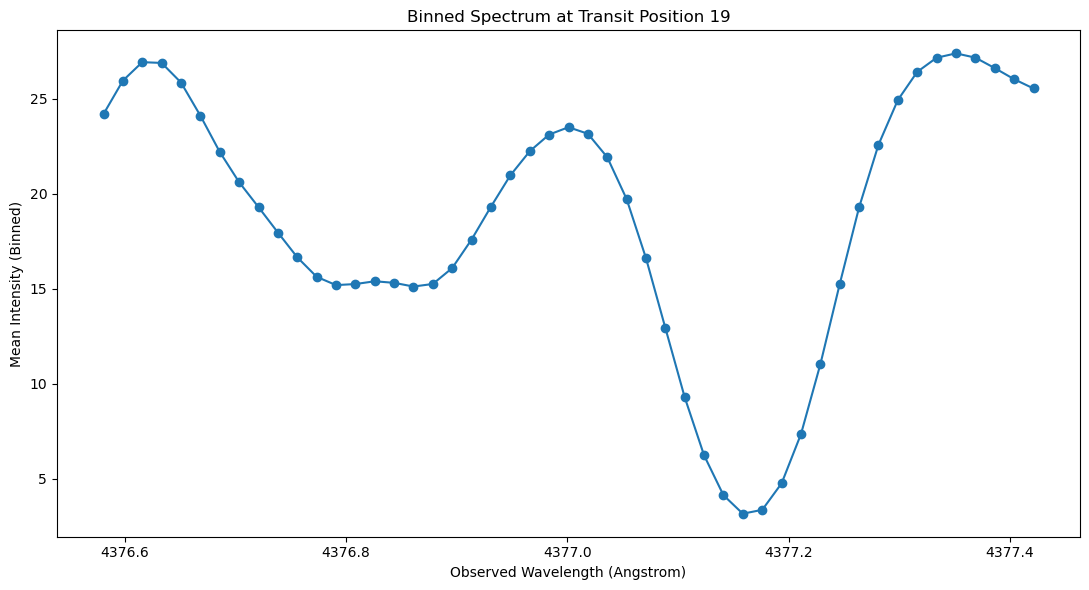

Number of valid bins: 49


In [43]:
# Bin the scattered pixel intensities onto the same wavelength grid as the input files (same edge-handling
# as 1_analyze_disks.ipynb, dropping bins within max_shift of either edge where the shift correction is
# incomplete)
max_shift = np.abs(wavelength_shifts_t).max()
wl_min_edge = wavelengths_t.min() + max_shift
wl_max_edge = wavelengths_t.max() - max_shift

midpoints = [(wavelengths_t[i] + wavelengths_t[i + 1]) / 2 for i in range(len(wavelengths_t) - 1)]
left_edge = wavelengths_t[0] - (midpoints[0] - wavelengths_t[0])
right_edge = wavelengths_t[-1] + (wavelengths_t[-1] - midpoints[-1])
bin_edges_t = np.array([left_edge, *midpoints, right_edge], dtype=float)

valid_bins_mask = (bin_edges_t[:-1] >= wl_min_edge) & (bin_edges_t[1:] <= wl_max_edge)
bin_centers_t = wavelengths_t[valid_bins_mask]
valid_indices_t = np.where(valid_bins_mask)[0]

if len(bin_centers_t) == 0:
    raise ValueError(
        "No valid wavelength bins survived edge-trimming: the wavelength window "
        f"({wavelengths_t.min():.4f}-{wavelengths_t.max():.4f} A) is too narrow relative to "
        f"the Doppler shift range (+/-{max_shift:.4f} A). Use a wider wavelength grid, "
        "or a lower v_eq, or fewer edge wavelengths."
    )

def binned_spectrum(position_idx):
    shifted_lambda, intensity = doppler_shifted_spectrum(position_idx)
    binned = np.full(len(bin_centers_t), np.nan)
    for i, idx in enumerate(valid_indices_t):
        mask = (np.round(shifted_lambda, 10) >= np.round(bin_edges_t[idx], 10)) & \
               (np.round(shifted_lambda, 10) < np.round(bin_edges_t[idx + 1], 10))
        if mask.any():
            binned[i] = intensity[mask].sum() / mask.sum()
    return binned

spec_mid = binned_spectrum(position_idx)
plt.figure(figsize=(11, 6))
plt.plot(bin_centers_t, spec_mid, marker='o', linestyle='-', linewidth=1.5)
plt.xlabel('Observed Wavelength (Angstrom)')
plt.ylabel('Mean Intensity (Binned)')
plt.title(f'Binned Spectrum at Transit Position {position_idx}')
plt.tight_layout()
plt.show()

print(f'Number of valid bins: {len(bin_centers_t)}')

spectrum_vs_time shape (Position/Time, Wavelength bin): (49, 49)


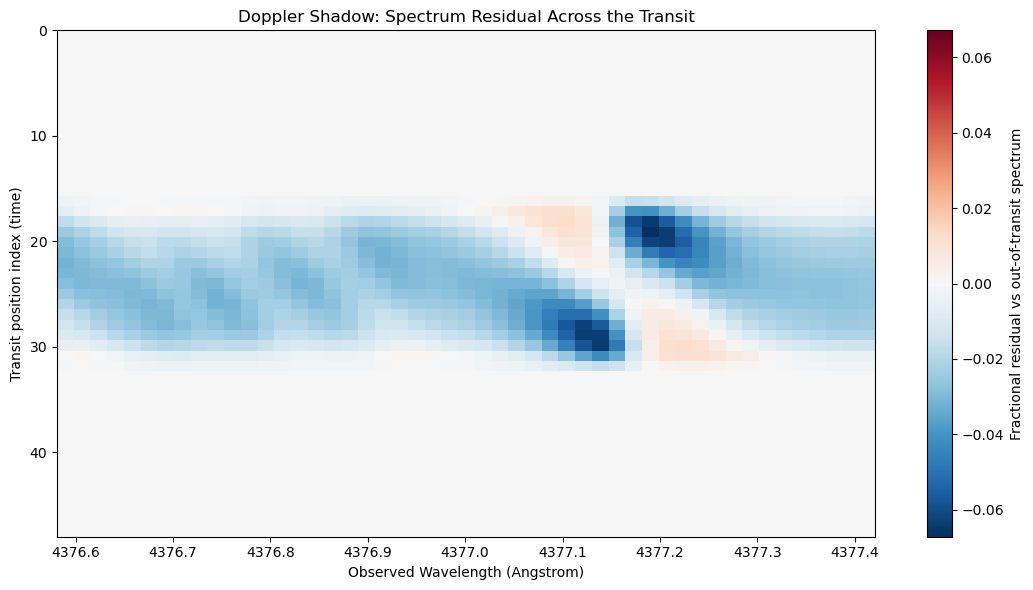

In [38]:
# Doppler shadow: binned spectrum at every transit time-step, stacked over time, shown relative to the
# out-of-transit (first position) spectrum. The planet blocks a different rotationally Doppler-shifted
# patch of the star at each time-step, so its shadow traces a moving feature in wavelength as time advances.
spectrum_vs_time = np.array([binned_spectrum(i) for i in range(n_positions)])
print("spectrum_vs_time shape (Position/Time, Wavelength bin):", spectrum_vs_time.shape)

baseline = spectrum_vs_time[0]  # first time-step, planet fully off the disc
residual = (spectrum_vs_time - baseline) / baseline

time_axis = np.arange(n_positions)  # swap for a physical time axis (e.g. from the transit_lc t array) if needed

vmax = np.nanmax(np.abs(residual))
plt.figure(figsize=(11, 6))
extent = [bin_centers_t.min(), bin_centers_t.max(), time_axis.max(), time_axis.min()]
im = plt.imshow(residual, aspect='auto', extent=extent, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, label='Fractional residual vs out-of-transit spectrum')
plt.xlabel('Observed Wavelength (Angstrom)')
plt.ylabel('Transit position index (time)')
plt.title('Doppler Shadow: Spectrum Residual Across the Transit')
plt.tight_layout()
plt.show()

## Doppler shift map with the transiting planet's mask overlaid

Shows the star's rotational Doppler-shift map (`wavelength_shifts_by_wl`) with the planet's aperture
drawn on top at a chosen transit position, and a multi-panel view sweeping across the whole transit —
same coordinate frame `transit_lc` itself uses to build/mask the discs (`transitpos`'s `X = X + size/2`,
`Y = Y + size/2`), so the circle lines up with the disc pixel-for-pixel.

In [39]:
# Recover the planet radius (in the same padded-disc pixel units used by transit_lc/transitpos) from the
# header written alongside the data, rather than hardcoding it
with open(pos_file, 'r') as f:
    header_line = f.readline()

def parse_header_value(name, header):
    m = re.search(rf'{name}=([-0-9.eE]+)', header)
    if m is None:
        raise ValueError(f"Could not find '{name}=' in header: {header}")
    return float(m.group(1))

radratio = parse_header_value('rp', header_line)
res2d = parse_header_value('res2d', header_line)
Rp_pixels = radratio * (res2d / 2)
print(f'radratio={radratio}, res2d={res2d}, Rp (pixels)={Rp_pixels:.2f}')

radratio=0.1808, res2d=30.0, Rp (pixels)=2.71


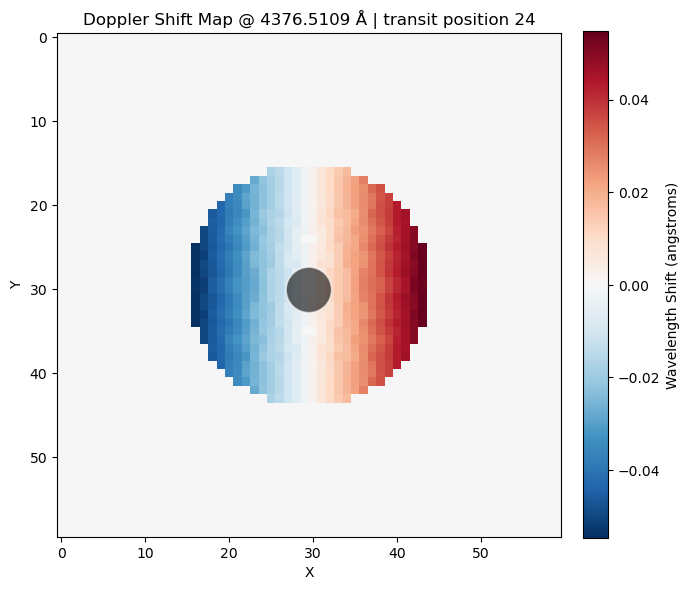

In [40]:
def plot_shift_with_planet(position_idx, wl_idx=0, ax=None, show_colorbar=True):
    """Doppler shift map (for wavelength wavelengths_t[wl_idx]) with the planet's aperture overlaid
    at transit position `position_idx`."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))

    shift_map = wavelength_shifts_t[wl_idx]
    vmax = np.abs(shift_map).max()
    im = ax.imshow(shift_map, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    if show_colorbar:
        plt.colorbar(im, ax=ax, label='Wavelength Shift (angstroms)', fraction=0.046, pad=0.04)

    planet = plt.Circle(positions[position_idx], Rp_pixels, facecolor='black', edgecolor='white',
                          alpha=0.6, linewidth=1.2, zorder=5)
    ax.add_artist(planet)

    ax.set_title(f'Doppler Shift Map @ {wavelengths_t[wl_idx]} \u00c5 | transit position {position_idx}')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    return ax

plot_shift_with_planet(position_idx)
plt.tight_layout()
plt.show()

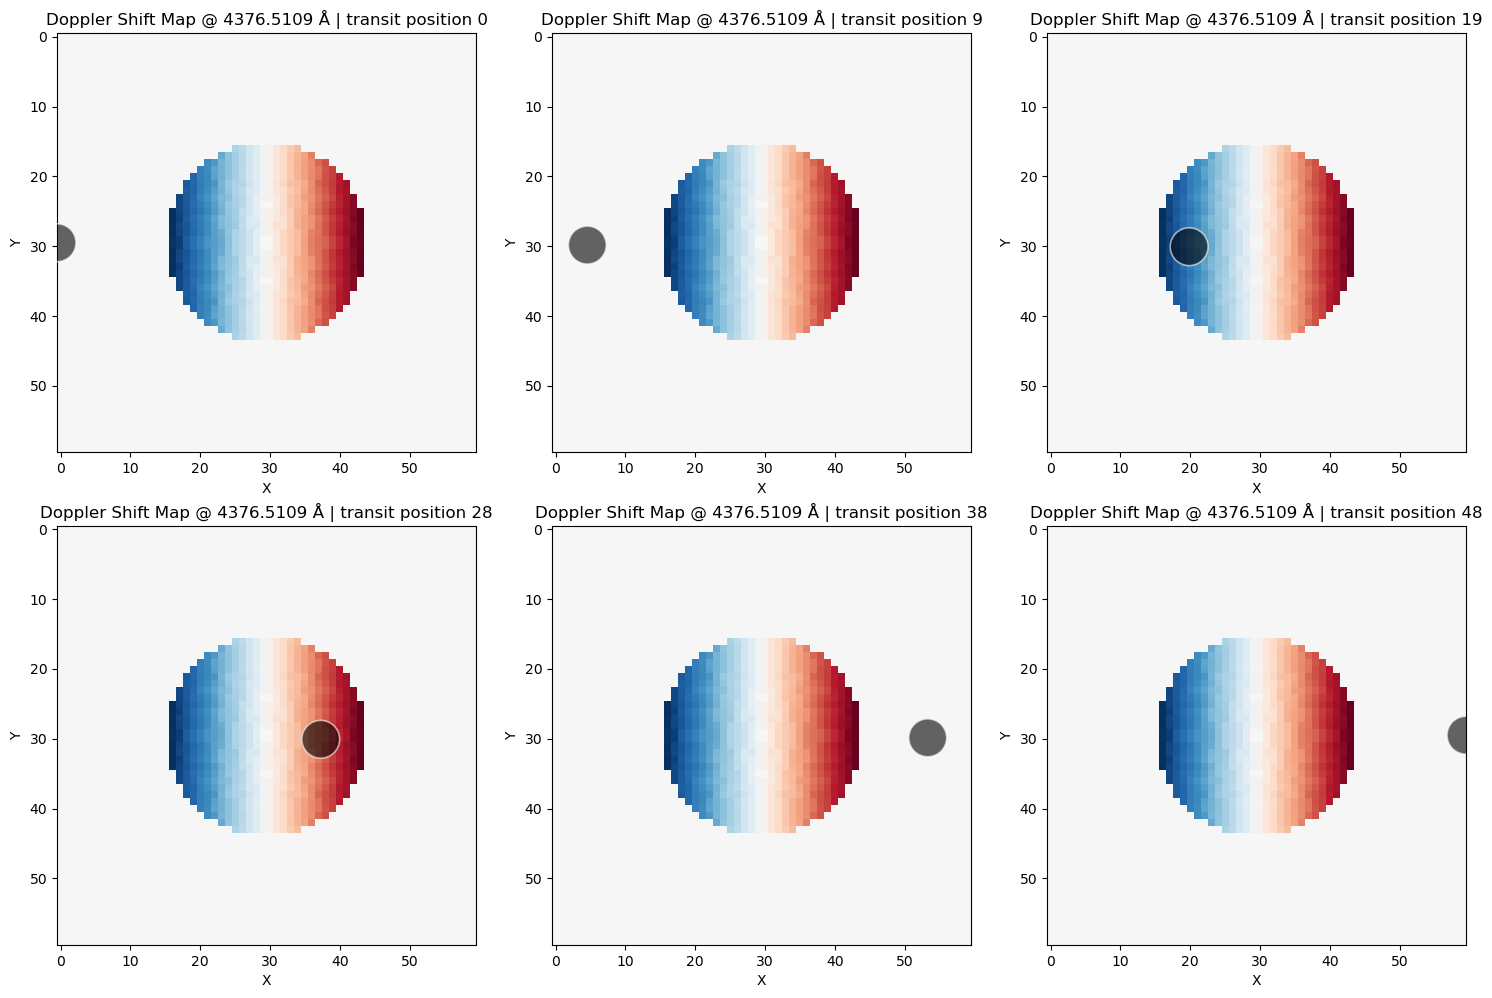

In [41]:
# Sweep across the whole transit: the planet moves left-to-right while the Doppler map underneath is fixed
# in the star's frame, so the panels show which rotational velocity (redshifted/blueshifted) region the
# planet is blocking at each moment.
n_panels = min(6, n_positions)
panel_indices = np.linspace(0, n_positions - 1, n_panels, dtype=int)

fig, axes = plt.subplots(2, (n_panels + 1) // 2, figsize=(5 * ((n_panels + 1) // 2), 10))
axes = np.atleast_1d(axes).ravel()

for ax, idx in zip(axes, panel_indices):
    plot_shift_with_planet(idx, ax=ax, show_colorbar=False)

for ax in axes[len(panel_indices):]:
    ax.axis('off')

fig.tight_layout()
plt.show()